## IN_DATA
- `dat_traj`

## OUT_DATA
- `dat_map_{job}`

## VERSION

## PACKAGE

In [ ]:
%load_ext autoreload
%autoreload 2

from src.utils import *
from src.metadata import *
from src.sparsemap import *

warnings.filterwarnings("ignore", category=RuntimeWarning)

## BASH PARAMETERS

In [ ]:
job_id = 14#14#int(sys.argv[1])

In [ ]:
in_dir = project_dir / "results"
out_dir = project_dir / "results" / "data_map"
#
if not os.path.exists(out_dir):
    os.makedirs(out_dir)

In [ ]:
# load tile trajectories
dat_traj_dict = pickle.load(open(in_dir / "dat_traj_dict", "rb"))

## SPECIFY ONE JOB BATCH
1. Select a subset of `dat_traj_dict` with a `pi_level` as a batch of jobs to run on cluster
2. the key for reading `dat_traj_dict` is `(type_id, id_1, id_2)` to output the value `(s_traj, a_traj, occ_map, s_top, xy_traj)`
3. for loading a mouse trajectory, use:
    - `type_id = 1`
    - `id_1` = 3 or 4 or ... (mouse_id)
    - `id_2` = 0 or 1 ... or 5 (rotation_id)
4. for loading a random trajectory, use:
    - `type_id = 0`
    - `id_1` = 0 or 1 or ... (seed)
    - `id_2` = -1 (-1 to specify n/a)
5. load a job as a nested tuple `((type_id, id_1, id_2), pi_level)`

In [ ]:
# # TEST PILOT BATCH: 1 pi_level, 6 traj for one mouse + 5 random trajectories (11K)
# pi_level = 80
# job_batch = {
#     1: ((0,0,-1), pi_level), 
#     2: ((0,1,-1), pi_level), 
#     3: ((0,2,-1), pi_level), 
#     4: ((0,3,-1), pi_level), 
#     5: ((0,4,-1), pi_level),
#     6: ((1,3,0), pi_level), 
#     7: ((1,3,1), pi_level), 
#     8: ((1,3,2), pi_level), 
#     9: ((1,3,3), pi_level), 
#     10: ((1,3,4), pi_level), 
#     11: ((1,3,5), pi_level),
#     12: ((1,4,0), pi_level),
#     13: ((1,4,1), pi_level),
#     14: ((1,4,2), pi_level),
#     15: ((1,4,3), pi_level),
#     16: ((1,4,4), pi_level),
#     17: ((1,4,5), pi_level),
# }
# len(job_batch)

In [ ]:
# FULL PILOT BATCH: 10 pi_level, 6 traj for one mouse + 5 random trajectories (70K)
mouse_id = 3
seed_list = np.arange(5)
rotation_id_list = np.arange(6)
pi_level_list = np.arange(0, 91, 10)

# get job lists
job_list_rand = [((0,seed,-1), pi_lev) for pi_lev in pi_level_list for seed in seed_list]
job_list_mouse = [((1,mouse_id,rot_id), pi_lev) for pi_lev in pi_level_list for rot_id in rotation_id_list]

# pack
job_batch = {i+1: job for i, job in enumerate(job_list_rand + job_list_mouse)}
len(job_batch)

110

In [ ]:
job_batch[job_id]

((0, 3, -1), 20)

## LOCAL PARAMETERS

In [ ]:
debug = False
n_parallel = 25

## PREP
### setting up belief distribution propagation

In [ ]:
# prep: maze dictionaries
hex_0_grid, hex_1_grid, s_z_dict, s_hex_dict, hex_a_dict, xy_s_dict, a_dict, sas_dict, ssa_dict, s_nbr_dict = load_maze_dicts(maze)

# prep: map
sh_dz_arr = get_sh_dz_arr(s_z_dict, sas_dict)
e_sh_arr = get_e_sh_arr(n_tiles, ringsize)
pq_mask_amb_dict = get_pq_mask_dict_for_ambiguous_edges(sh_dz_arr)

# prep: pi & tile transition tensor
pi_all = get_p_vonmises_for_enumPI()
T = get_T_tensor(sas_dict, ringsize, n_tiles)
T_dict = get_T_tensor_dict(T, ringsize)

## LOAD JOB

In [ ]:
# check if the saved file exists
dat_path = out_dir / f"dat_map_{job_batch[job_id]}"
dat_exists = os.path.exists(dat_path)

In [ ]:
key, pi_level = job_batch[job_id]
s_traj, a_traj, occ_map, s_top, xy_traj = dat_traj_dict[key]
pi = pi_all[pi_level]

## RUN: map optimization

### DEV: improving optimizer
1. **issue**: 
    - short traj chunk might not cover some s_top, which could result an immature deletion.
2. **sol**: 
    - set lower priority to delete unoccupied edges (not even evaluating them?)
    - delete a highly occupied edge (in chunk) when tie (softmax deletion? try hard deletion first)
    - or should we delete lowly occupied edge?
3. **rationale**:
    - when tie, highly occupied edges likely are less informative than lowly occupied one. because local scores are preserved on many revisits after deletion.
4. never occupied edges should be deleted first

### src

In [ ]:
# def get_eid_from_s(s_list, e_sh_arr):
#     '''Get edge IDs from a list of states.'''
#     eid_list = []
#     for s in s_list:
#         eid_list += list(np.where(e_sh_arr[:,0] == s)[0])
#     return np.array(eid_list)

# def get_eid_cand_for_one_iter(eid_remain, s_traj, e_sh_arr, n_tiles):
#     '''Get candidate edges from the remaining sorted by occupancy (least to most occupied).'''
#     # get occupied tiles & sort by occupancy
#     occ_map = get_occ_map_from_s_traj(s_traj, n_tiles)[0]
#     s_nz = np.where(occ_map > 0)[0]
#     s_sort = np.argsort(occ_map) # least to most
#     s_sort_nz = s_sort[np.isin(s_sort, s_nz)]

#     # get occupied edges
#     eid_sort_nz = get_eid_from_s(s_sort_nz, e_sh_arr)

#     # get candidates from remaining edges with non-zero occupancy
#     eid_remain_nz = eid_sort_nz[np.isin(eid_sort_nz, eid_remain)]
#     return eid_remain_nz

# def get_one_traj_chunk(s_traj, a_traj, chunk_id, chunksize):
#     if chunk_id is None:
#         return s_traj, a_traj
#     else:
#         s_traj_r = s_traj[chunk_id*chunksize:(chunk_id+1)*chunksize]
#         a_traj_r = a_traj[chunk_id*chunksize:(chunk_id+1)*chunksize]
#         return s_traj_r, a_traj_r

In [ ]:
def run_map_optimizer(s_traj, a_traj, occ_map, s_top, pi, schedule):
    '''
    NOTE: 
    '''
    # mp
    def run_mp(param):
        # load
        map, chunk_id, chunksize = param
        
        # load chunk of trajectory
        s_traj_r, a_traj_r = get_one_traj_chunk(s_traj, a_traj, chunk_id, chunksize)
        
        # eval
        score, score_map = eval_one_map(map, s_traj_r, a_traj_r, s_top, T_dict, pi, e_sh_arr, pq_mask_amb_dict, n_tiles, ringsize, n_edges, sh_dz_arr)
        return score, score_map
    
    # eval full map
    score_max, _ = run_mp((np.arange(n_edges), None, None))

    # initialize
    s_removed = np.where(occ_map==0)[0]
    eid_removed = list(get_eid_from_s(s_removed, e_sh_arr)) # remove unoccupied edges first
    eid_remain = np.arange(n_edges)
    eid_remain = eid_remain[~np.isin(eid_remain, eid_removed)]
    score_iter = [score_max]

    # iter
    if len(eid_removed) > 0:
        print(f'skipping first {len(eid_removed)} iterations due to unoccupied edges')
    for iter in np.arange(len(eid_removed), len(schedule)):
        # load schedule
        n_chunks, chunk_id, chunksize = schedule[iter]
        
        # find candidate edges to remove
        for subiter in range(n_chunks):
            s_traj_r, _ = get_one_traj_chunk(s_traj, a_traj, chunk_id, chunksize)
            eid_cand = get_eid_cand_for_one_iter(eid_remain, s_traj_r, e_sh_arr, n_tiles)
            if len(eid_cand) > 0:
                break
            else:
                print(f"chunk {chunk_id} has no candidate edges to remove, trying next chunk...")
                chunk_id = (chunk_id + 1) % n_chunks # override until eid_cand is non-empty
        
        # eval candidates on one traj chunk
        eid_remain_cand = [eid_remain[eid_remain!=x] for x in eid_cand]
        param = [(x, chunk_id, chunksize) for x in eid_remain_cand]
        with multiprocess.Pool() as p:
            score_cand, _ = zip(*p.map(run_mp, param))
        
        # find top
        idx_top = np.argmax(score_cand)
        eid_top = eid_cand[idx_top] # top to be removed
        score_top = score_cand[idx_top]
        eid_remain = eid_remain_cand[idx_top]

        # append
        eid_removed.append(eid_top)
        score_iter.append(score_top)
        
        # print
        print(f"iter {iter}: eval {len(eid_cand)} edges, remove edge {eid_top}, score = {score_top:.6f}, chunk_id = {chunk_id}/{n_chunks}")
    return score_iter, eid_removed

def eval_multiple_maps(map_list, s_traj, a_traj, s_top, pi):
    '''
    NOTE: 
    '''
    def run_mp(map):
        score, score_map = eval_one_map(map, s_traj, a_traj, s_top, T_dict, pi, e_sh_arr, pq_mask_amb_dict, n_tiles, ringsize, n_edges, sh_dz_arr)
        return score, score_map
    
    # mp
    with multiprocess.Pool() as p:
        score_list, score_map_list = zip(*p.map(run_mp, map_list))
    score_list = np.array(score_list)
    return score_list, score_map_list

In [14]:
## RUN (100m)
# if not dat_exists:
if True:
    # get optimization schedule
    schedule = get_optimization_schedule(n_parallel, n_edges, s_traj)
    # schedule = {x:schedule[x] for x in range(100)} # TEST RUN

    # run optimization
    score_iter, eid_removed = run_map_optimizer(s_traj, a_traj, occ_map, s_top, pi, schedule)

    # eval all maps on full trajectory
    print('evaluating all maps on full trajectory...')
    map_iter = get_map_list_from_eid_removed(eid_removed, n_edges)
    score_iter_full, score_map_iter_full = eval_multiple_maps(map_iter, s_traj, a_traj, s_top, pi)

iter 0: eval 648 edges, remove edge 258, score = 0.713508, chunk_id = 0/37
iter 1: eval 677 edges, remove edge 228, score = 0.838159, chunk_id = 1/37
iter 2: eval 712 edges, remove edge 734, score = 0.814476, chunk_id = 2/37
iter 3: eval 694 edges, remove edge 816, score = 0.754839, chunk_id = 3/37
iter 4: eval 800 edges, remove edge 450, score = 0.914052, chunk_id = 4/37
iter 5: eval 727 edges, remove edge 264, score = 0.920258, chunk_id = 5/37
iter 6: eval 786 edges, remove edge 594, score = 0.910299, chunk_id = 6/36
iter 7: eval 750 edges, remove edge 372, score = 0.843074, chunk_id = 7/36
iter 8: eval 599 edges, remove edge 9, score = 0.746409, chunk_id = 8/36
iter 9: eval 654 edges, remove edge 336, score = 0.815917, chunk_id = 9/36
iter 10: eval 720 edges, remove edge 827, score = 0.813477, chunk_id = 10/36
iter 11: eval 711 edges, remove edge 270, score = 0.860070, chunk_id = 11/36
iter 12: eval 521 edges, remove edge 588, score = 0.719214, chunk_id = 12/36
iter 13: eval 741 edg

## PICKLE

In [11]:
if not dat_exists:
    dat_map = score_iter_full, score_map_iter_full, eid_removed
    pickle.dump(dat_map, open(dat_path, "wb"))
    
else:
    score_iter_full, score_map_iter_full, eid_removed = pickle.load(open(dat_path, "rb"))

## TEST

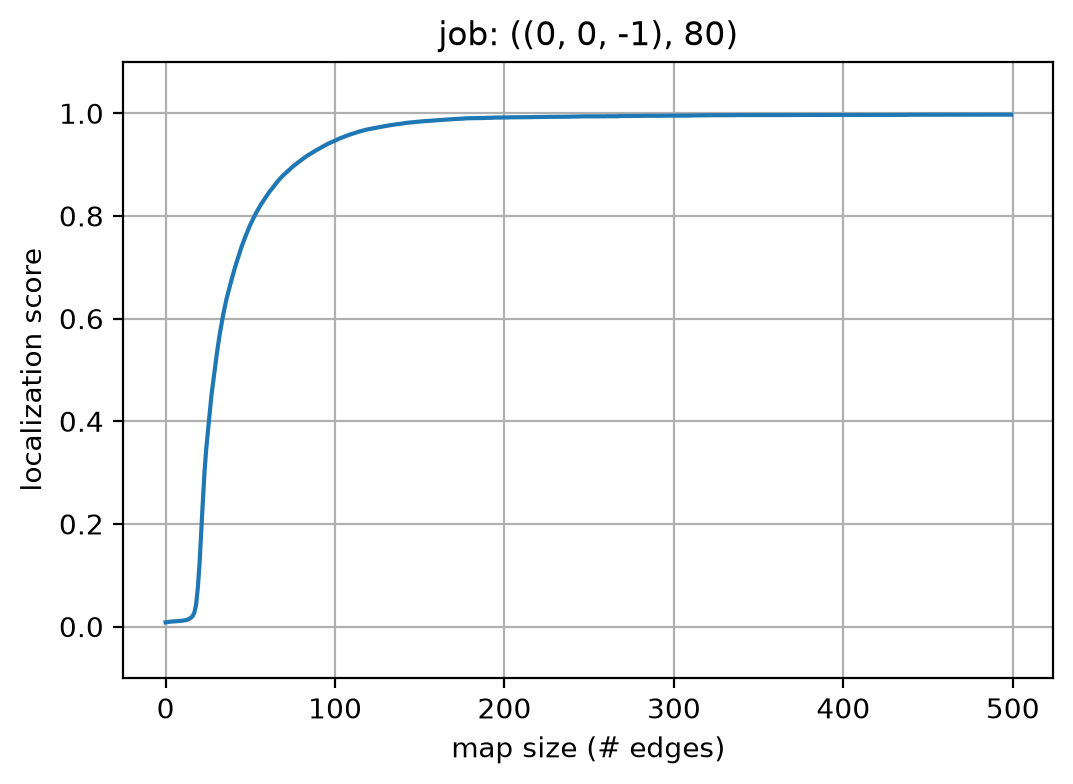

In [14]:
n_plot = 500

# plot
map_iter = get_map_list_from_eid_removed(eid_removed, n_edges)
mapsize_iter = [len(x) for x in map_iter]
plt.figure(figsize=(6,4), dpi=200)
plt.title(f"job: {job_batch[job_id]}")
plt.plot(mapsize_iter[::-1][:n_plot], score_iter_full[::-1][:n_plot])
plt.xlabel('map size (# edges)')
plt.ylabel('localization score')
plt.ylim([-.1,1.1])
plt.grid()

if not os.path.exists(out_dir / 'plot'):
    os.makedirs(out_dir / 'plot')
plt.savefig(out_dir / 'plot' / f"map_score_{job_batch[job_id]}.png")

# TEST batch

### test pilot (two mice)

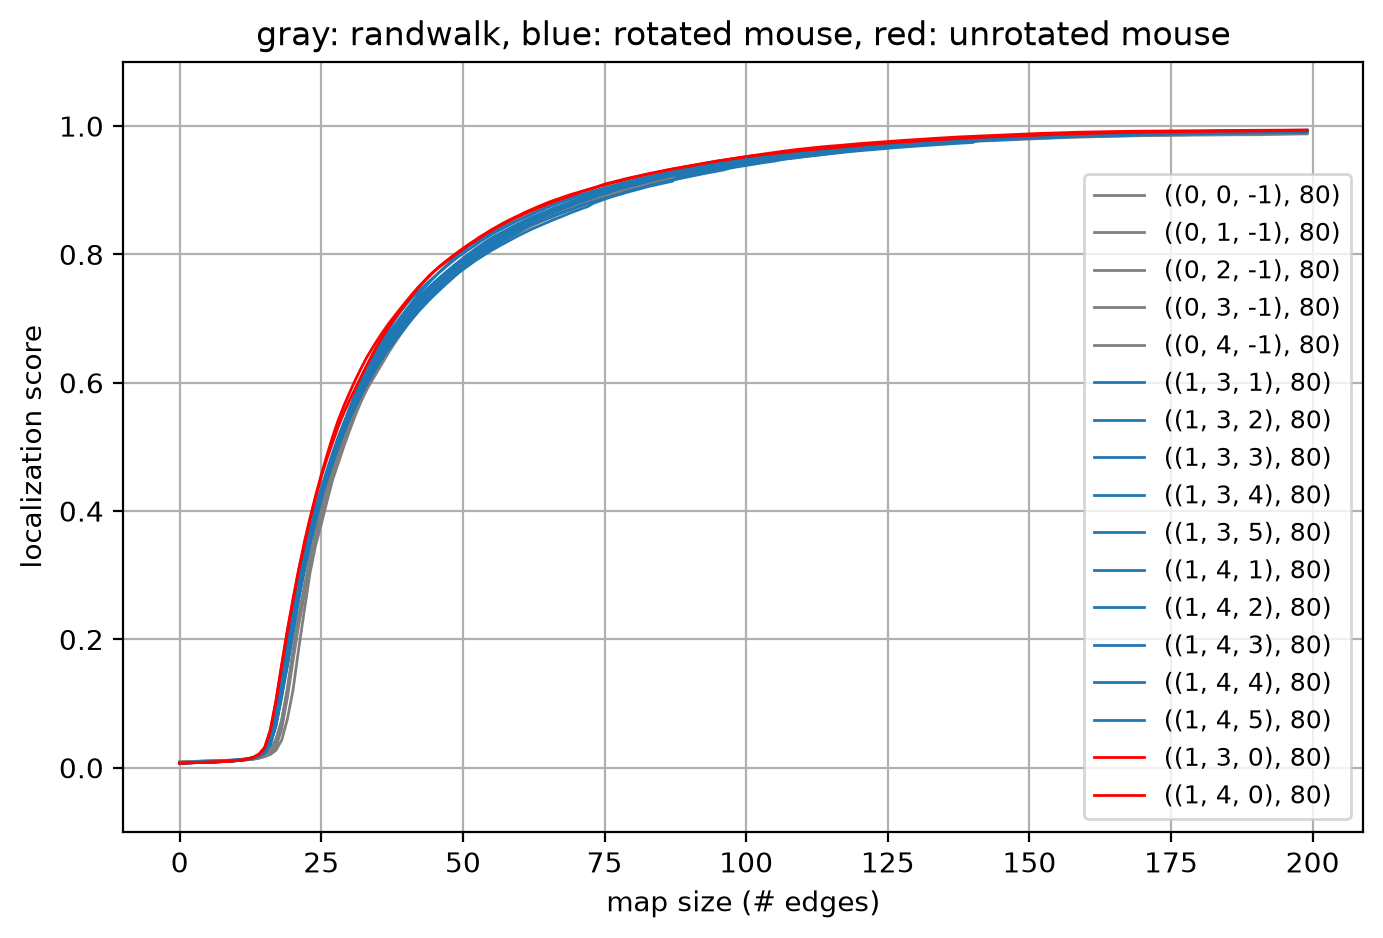

In [38]:
job_selected = [1,2,3,4,5] + [7,8,9,10,11,13,14,15,16,17] + [6,12]
n_plot = 200

# plot
mapsize_iter = np.arange(n_edges, -1, -1)
colors = ['tab:gray']*5 + ['tab:blue']*10 + ['red']*2
plt.figure(figsize=(8,5), dpi=200)
plt.title('gray: randwalk, blue: rotated mouse, red: unrotated mouse')
for i, job_id in enumerate(job_selected):
    dat_path = out_dir / f"dat_map_{job_batch[job_id]}"
    score_iter_full, score_map_iter_full, eid_removed = pickle.load(open(dat_path, "rb"))
    plt.plot(mapsize_iter[::-1][:n_plot], score_iter_full[::-1][:n_plot], label=f'{job_batch[job_id]}', lw=1, color=colors[i])
plt.xlabel('map size (# edges)')
plt.ylabel('localization score')
plt.ylim([-.1,1.1])
plt.grid()
plt.legend(fontsize=9)

# if not os.path.exists(out_dir / 'plot'):
    # os.makedirs(out_dir / 'plot')
# plt.savefig(out_dir / 'plot' / f"map_score_{job_batch[job_id]}.png")

### full pilot (mouse 3)

In [12]:
job_id = 1
score_iter_full, score_map_iter_full, eid_removed = pickle.load(open(out_dir / f"dat_map_{job_batch[job_id]}", "rb"))

In [13]:
job_selected = np.arange(1, 51)
score_tensor = np.array([pickle.load(open(out_dir / f"dat_map_{job_batch[job_id]}", "rb"))[0] for job_id in job_selected]).reshape(10,5,-1)
score_arr = score_tensor.mean(1)[:,::-1]
mapsize_50 = [np.argmin(np.abs(x-.5)) for x in score_arr]
mapsize_60 = [np.argmin(np.abs(x-.6)) for x in score_arr]
mapsize_70 = [np.argmin(np.abs(x-.7)) for x in score_arr]

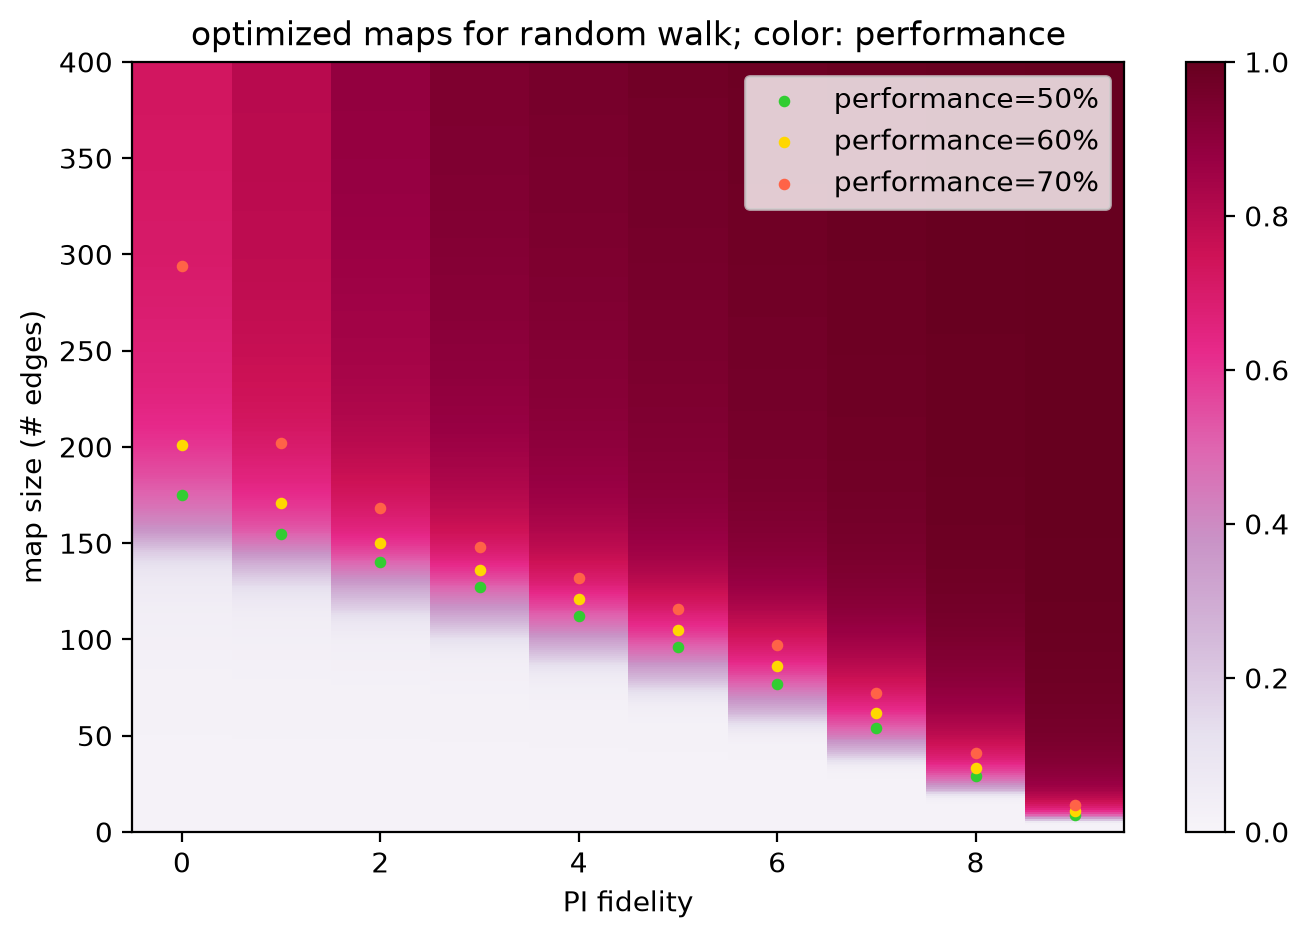

In [14]:
plt.figure(figsize=(8,5), dpi=200)
plt.title('optimized maps for random walk; color: performance')
plt.imshow(score_arr.T, aspect='auto', cmap='PuRd', origin='lower', vmin=0, vmax=1, interpolation='nearest')
plt.colorbar()
plt.scatter(np.arange(10), mapsize_50, color='limegreen', s=10, label='performance=50%')
plt.scatter(np.arange(10), mapsize_60, color='gold', s=10, label='performance=60%')
plt.scatter(np.arange(10), mapsize_70, color='tomato', s=10, label='performance=70%')
plt.ylim([0, 400])
plt.xlabel('PI fidelity')
plt.ylabel('map size (# edges)')
plt.legend()

(0.995, 1.001)

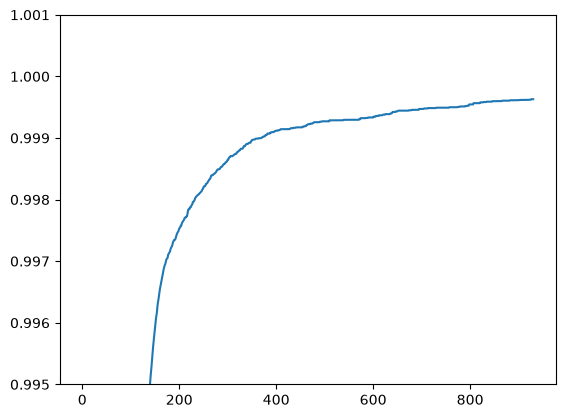

In [20]:
plt.plot(score_arr[9,:], label=f'PI={i*10}')
plt.ylim(.995,1.001)

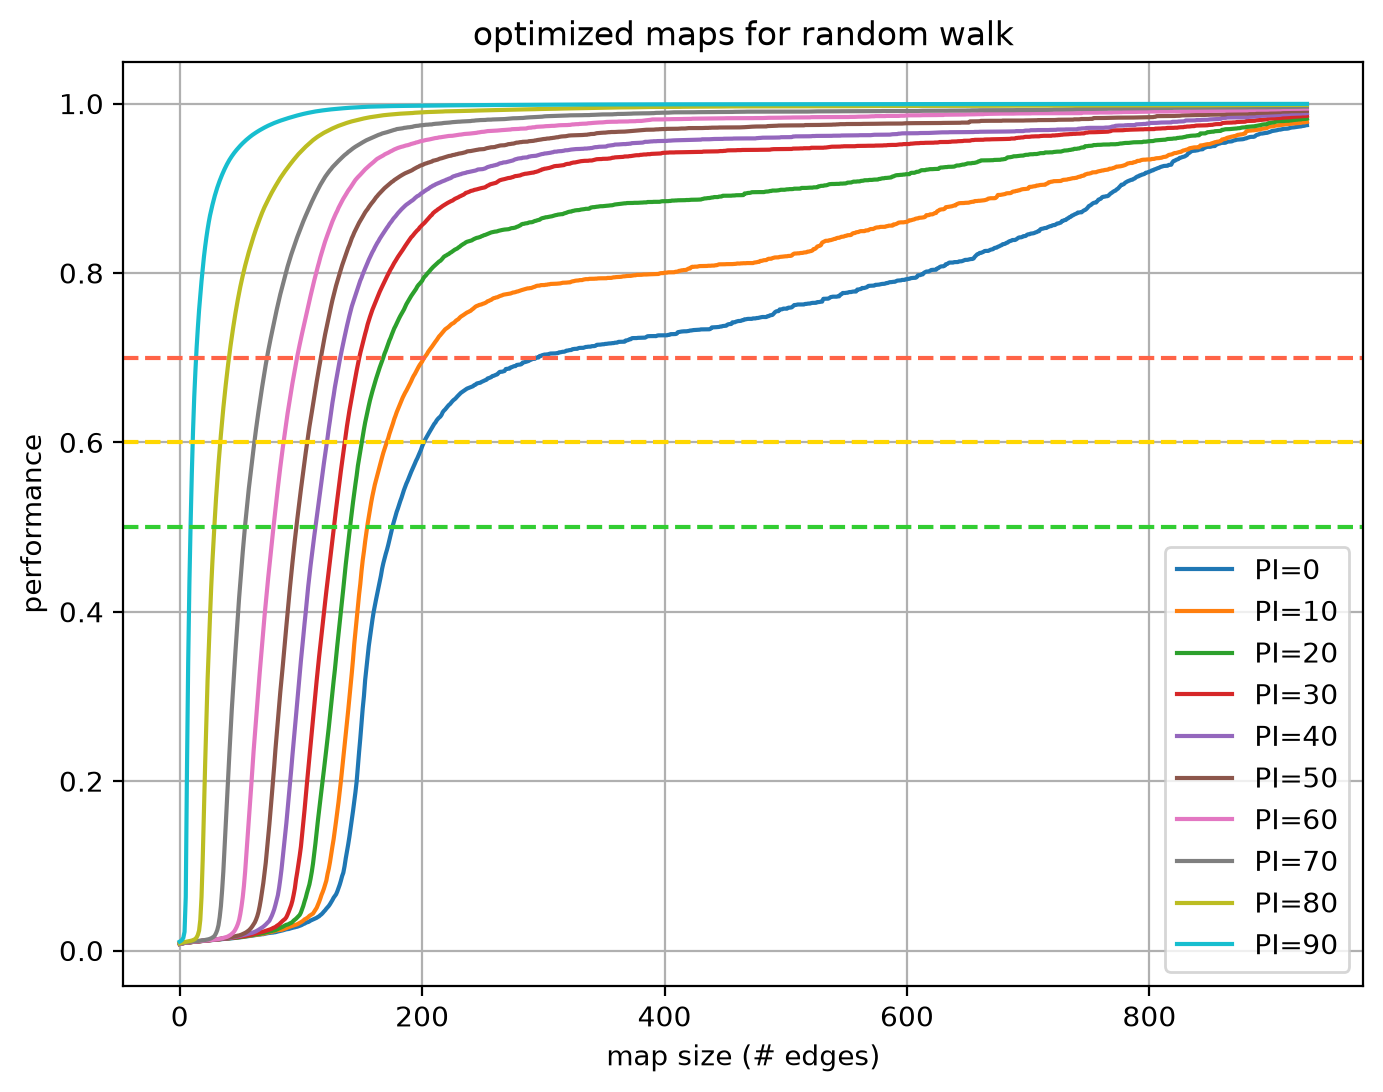

In [15]:
plt.figure(figsize=(8,6), dpi=200)
plt.title('optimized maps for random walk')
for i,x in enumerate(score_arr[:,:]): plt.plot(x, label=f'PI={i*10}')
for y,c in zip([.5,.6,.7], ['limegreen', 'gold', 'tomato']): 
    plt.axhline(y, color=c, linestyle='--')
plt.xlabel('map size (# edges)')
plt.ylabel('performance')
plt.legend()
plt.grid()

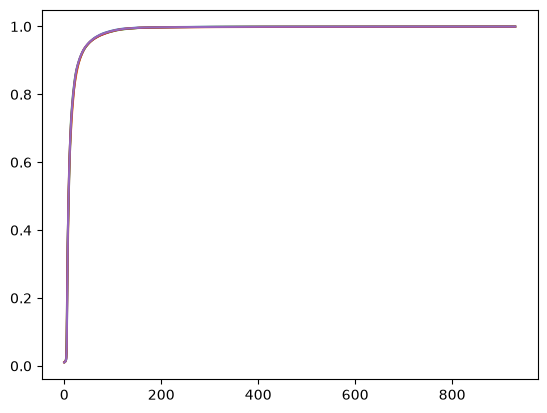

In [220]:
plt.plot(score_tensor[9,:,::-1][:,:].T)

In [73]:
np.arange(50).reshape(10,5)

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14],
       [15, 16, 17, 18, 19],
       [20, 21, 22, 23, 24],
       [25, 26, 27, 28, 29],
       [30, 31, 32, 33, 34],
       [35, 36, 37, 38, 39],
       [40, 41, 42, 43, 44],
       [45, 46, 47, 48, 49]])

In [70]:
score_iter_arr.reshape(5,10,-1)

array([[[0.98044981, 0.98030522, 0.98021326, ..., 0.00856815,
         0.00825733, 0.00772962],
        [0.96616731, 0.96621154, 0.96621154, ..., 0.00809259,
         0.0077083 , 0.00730185],
        [0.97360679, 0.97360679, 0.97360679, ..., 0.00837402,
         0.00816745, 0.00786378],
        ...,
        [0.97804757, 0.97804757, 0.97802965, ..., 0.00839509,
         0.00814492, 0.00786878],
        [0.97998941, 0.97998941, 0.97951195, ..., 0.0087083 ,
         0.00855098, 0.00835478],
        [0.97933004, 0.97761835, 0.97672766, ..., 0.0087168 ,
         0.00829335, 0.00783497]],

       [[0.98620407, 0.9861995 , 0.98616173, ..., 0.0085811 ,
         0.00826336, 0.00773091],
        [0.97646224, 0.97652877, 0.97652877, ..., 0.00809743,
         0.00781401, 0.00731811],
        [0.98232447, 0.98232447, 0.98231549, ..., 0.00840054,
         0.00815606, 0.00787673],
        ...,
        [0.98605401, 0.98605401, 0.9860495 , ..., 0.0084079 ,
         0.00817238, 0.0078889 ],
        [0.9

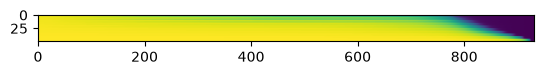

In [67]:
plt.imshow(score_iter_arr)

In [ ]:
n_plot = 200

# plot
mapsize_iter = np.arange(n_edges, -1, -1)
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan']
plt.figure(figsize=(8,5), dpi=200)
plt.title('pilot')
for i, job_id in enumerate(job_selected):
    dat_path = out_dir / f"dat_map_{job_batch[job_id]}"
    score_iter_full, score_map_iter_full, eid_removed = pickle.load(open(dat_path, "rb"))
    plt.plot(mapsize_iter[::-1][:n_plot], score_iter_full[::-1][:n_plot], label=f'{job_batch[job_id]}', lw=1, color=colors[i])
plt.xlabel('map size (# edges)')
plt.ylabel('localization score')
plt.ylim([-.1,1.1])
plt.grid()
plt.legend(fontsize=9)

# if not os.path.exists(out_dir / 'plot'):
    # os.makedirs(out_dir / 'plot')
# plt.savefig(out_dir / 'plot' / f"map_score_{job_batch[job_id]}.png")